In [1]:
import pandas as pd
import numpy as np
from collections import defaultdict

import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt

# set font size to 20
plt.rcParams.update({'font.size': 40})
# set default line width to 3
plt.rcParams['lines.linewidth'] = 5
# set marker size to 10
plt.rcParams['lines.markersize'] = 15

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# Learning tasks are executed in the following temporal order
# tasks = ["Portmap", "LDAP", "MSSQL", "UDP", "UDPLag", "Syn"]

In [2]:
tasks = ["Portmap", "LDAP", "MSSQL", "UDP", "UDPLag", "Syn"]
data = defaultdict(list)

In [3]:
cl_avg_task_accuracy = [[0.9964801126363957, 0.9065065117916227, 0.9293857762967805, 0.941466725851767, 0.952128673184766, 0.9586050703849006],
[0.9971840901091165, 0.9678028863076382, 0.8739044257178881, 0.8938713496463597, 0.9193464379798628, 0.9332990392239675],
[0.9961281239000352, 0.9381226680746216, 0.9469581173283195, 0.9513164364301024, 0.8459134443475088, 0.9666880086122629],
[0.9971840901091165, 0.9173074621612108, 0.9062209962435644, 0.9429163130063271, 0.950902021973293, 0.9537042078826291],
[0.9975360788454769, 0.9182235128475889, 0.9276772229704869, 0.9349213546896405, 0.9444859005260244, 0.9568718533109329]]
for i, row in enumerate(cl_avg_task_accuracy):
    data["Accuracy"] += row
    data["Learning tasks over the time"] += tasks
    data["Seed"] += [i] * len(row)
    data["Algorithm"] += ["CRF - w/ Continual + Active Learning"] * len(row)

In [4]:
online_avg_task_accuracy = [[0.9985920450545582, 0.6661666666666667, 0.5551580202742993, 0.5587146804643744, 0.5979554944259998, 0.66401552839142],
[0.9978880675818373, 0.6666666666666666, 0.5552456768038163, 0.5432941378287155, 0.5981067980838425, 0.6645179412588261],
[0.9992960225272791, 0.6665, 0.554824686940966, 0.5486820969489073, 0.5988460468764054, 0.6636268164792081],
[0.9985920450545582, 0.6659813445969729, 0.5547604849930431, 0.5267492265656281, 0.5989035877218029, 0.66288999513088],
[0.9989440337909187, 0.6663333333333333, 0.5551580202742993, 0.5227565172485613, 0.5987641132426488, 0.6684751099194214]]
for i, row in enumerate(online_avg_task_accuracy):
    data["Accuracy"] += row
    data["Learning tasks over the time"] += tasks
    data["Seed"] += [i] * len(row)
    data["Algorithm"] += ["ARF - w/o Continual + Active Learning"] * len(row)

In [5]:
# online_single_task_accuracy = [[0.9985920450545582, 0.999, 0.9988073941562313, 0.9952153110047847, 0.9979516591560835, 0.9956666666666667],
# [0.9978880675818373, 1.0, 0.9994036970781157, 0.9952153110047847, 0.9963129864809505, 0.9996666666666667],
# [0.9992960225272791, 0.9996666666666667, 0.9988073941562313, 0.9952153110047847, 0.9979516591560835, 0.9986666666666667],
# [0.9985920450545582, 0.9993333333333333, 0.9976147883124628, 0.9978734715576821, 0.9987709954936501, 1.0],
# [0.9989440337909187, 0.9993333333333333, 0.9988073941562313, 0.9968102073365231, 0.9975419909873003, 0.9986666666666667]]
# for i, row in enumerate(online_single_task_accuracy):
#     data["Accuracy"] += row
#     data["Learning Task"] += tasks
#     data["Seed"] += [i] * len(row)
#     data["Algorithm"] += ["ARF - Present Task"] * len(row)

In [6]:
full_model_accuracy = [0.9840296495956873, 0.9840970350404312, 0.984366576819407, 0.9832884097035041]

In [8]:
# put the data into a wide-form DataFrame
df = pd.DataFrame(data)
df.head()
df.to_csv("./results/accuracy.csv", index=False)

In [10]:
dataset_size_cl = [[0.22105405, 0.50680685, 0.7413398, 0.93408815, 1.02304893, 1.16727322],
[0.1994878, 0.31945006, 0.60520286, 0.7130341, 0.93408815, 1.02035315],
[0.22374983, 0.43132498, 0.70359887, 0.91791347, 0.94756706, 1.12009705],
[0.20218358, 0.43536865, 0.69685942, 0.86669362, 0.99069956, 1.09583502],
[0.23048928, 0.47310958, 0.69685942, 0.91117401, 1.12144494, 1.1834479]]
data_size = defaultdict(list)
for i, row in enumerate(dataset_size_cl):
    data_size["#Queries %"] += row
    data_size["Learning tasks over the time"] += tasks
    data_size["Seed"] += [i] * len(row)
    data_size["Algorithm"] += ["CRF - w/ Continual + Active Learning"] * len(row)
df_size = pd.DataFrame(data_size)
df_size.head()
df_size.to_csv("./results/sample_size.csv", index=False)

In [2]:
df = pd.read_csv("./results/accuracy.csv")
df_size = pd.read_csv("./results/sample_size.csv")

/var/folders/vm/0j00_qc959gd06bhgzyrw2ph0000gn/T/ipykernel_70529/2319629029.py:3: UserWarning: The markers list has more values (3) than needed (2), which may not be intended.
  sns.lineplot(x="Learning tasks over the time", y="Accuracy", hue="Algorithm", style='Algorithm', data=df, markers='o^v', legend=False, ax=ax2)


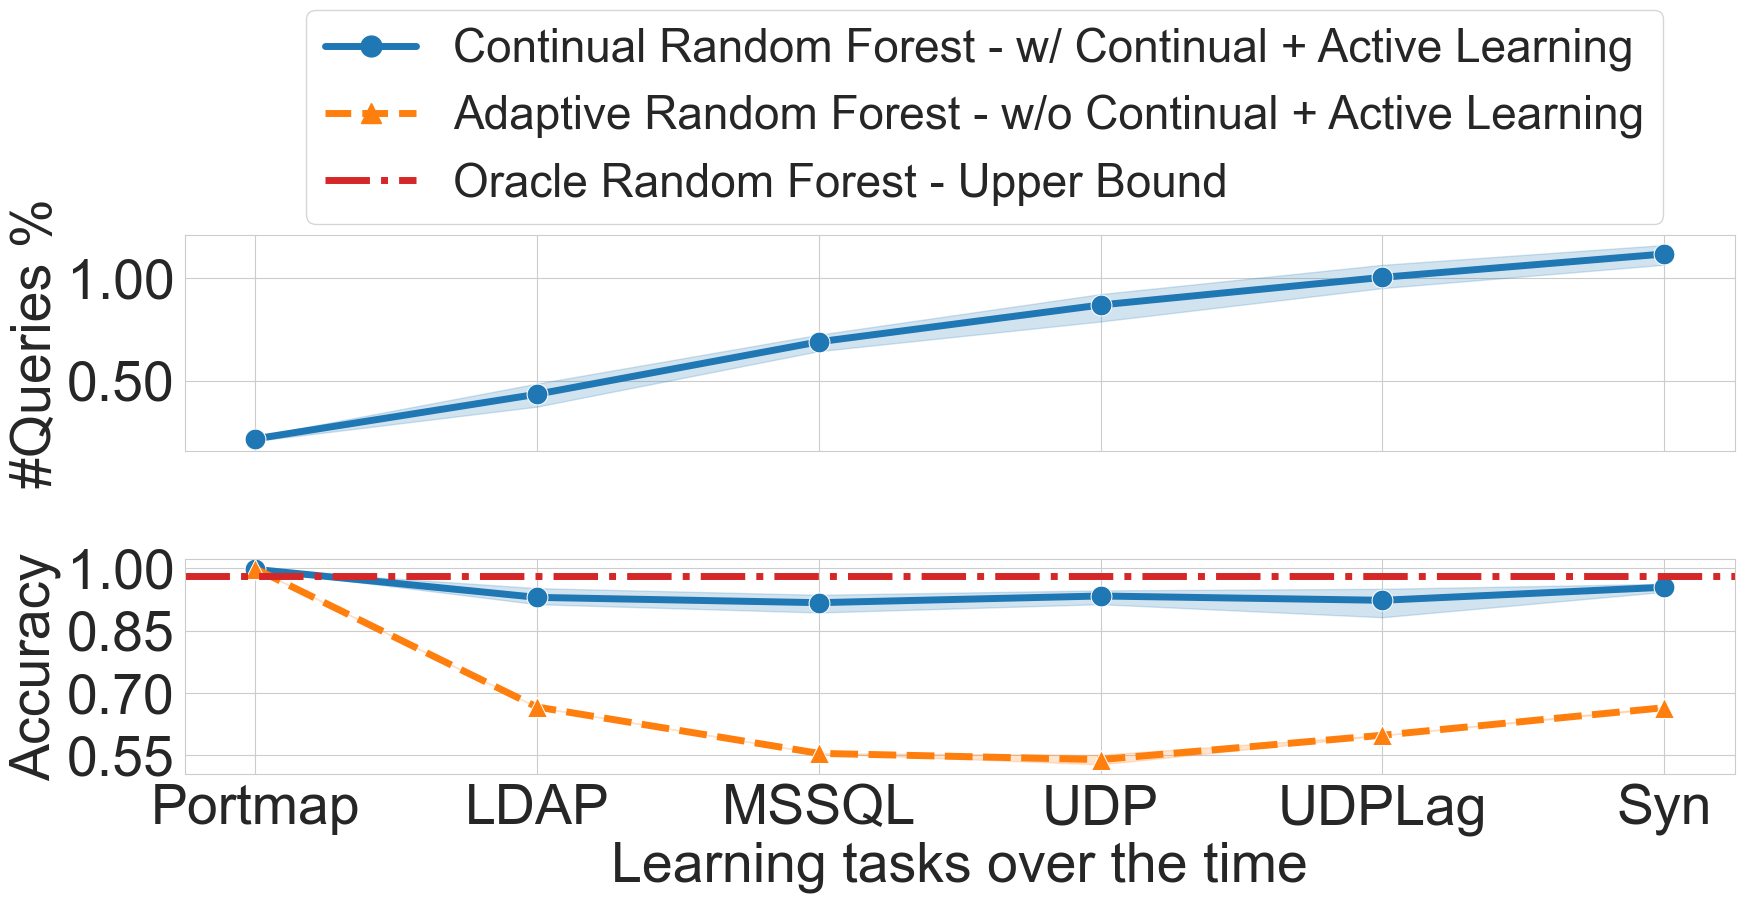

In [3]:
fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(20, 7), sharex=True, gridspec_kw={'height_ratios': [2, 2]})
sns.lineplot(x="Learning tasks over the time", y="#Queries %", style='Algorithm', data=df_size, markers='o', legend=False, ax=ax1)
sns.lineplot(x="Learning tasks over the time", y="Accuracy", hue="Algorithm", style='Algorithm', data=df, markers='o^v', legend=False, ax=ax2)
ax2.axhline(0.98, color='#d62728', linestyle='-.')
ax1.set_yticks([0.50, 1.00], ['0.50', '1.00'])
ax2.set_yticks([1.00, 0.85, 0.70, 0.55])
# make a custom legend that is the same of the second plot
from matplotlib.lines import Line2D

legend_elements = [Line2D([0], [0], color='#1f77b4', marker='o', lw=5, label='Continual Random Forest - w/ Continual + Active Learning'),
                   Line2D([0], [0], color='#ff7f0e', marker='^', lw=5, linestyle='--', label='Adaptive Random Forest - w/o Continual + Active Learning'),
                   # Line2D([0], [0], color='#2ca02c', marker='v', lw=5, linestyle=':', label='ARF - Present Tasks'),
                   Line2D([0], [0], color='#d62728', linestyle='-.', lw=5, label='Oracle Random Forest - Upper Bound')]
fig.legend(handles=legend_elements, bbox_to_anchor=(0.8755, 1.235), ncol=1, fontsize=33)
plt.subplots_adjust(hspace=0.5)
# plt.savefig("arf_crf_comparison.pdf", bbox_inches="tight")

/var/folders/vm/0j00_qc959gd06bhgzyrw2ph0000gn/T/ipykernel_70529/25733918.py:3: UserWarning: The markers list has more values (3) than needed (2), which may not be intended.
  sns.lineplot(x="Learning tasks over the time", y="Accuracy", hue="Algorithm", style='Algorithm', data=df, markers='o^v', legend=False, ax=ax2)


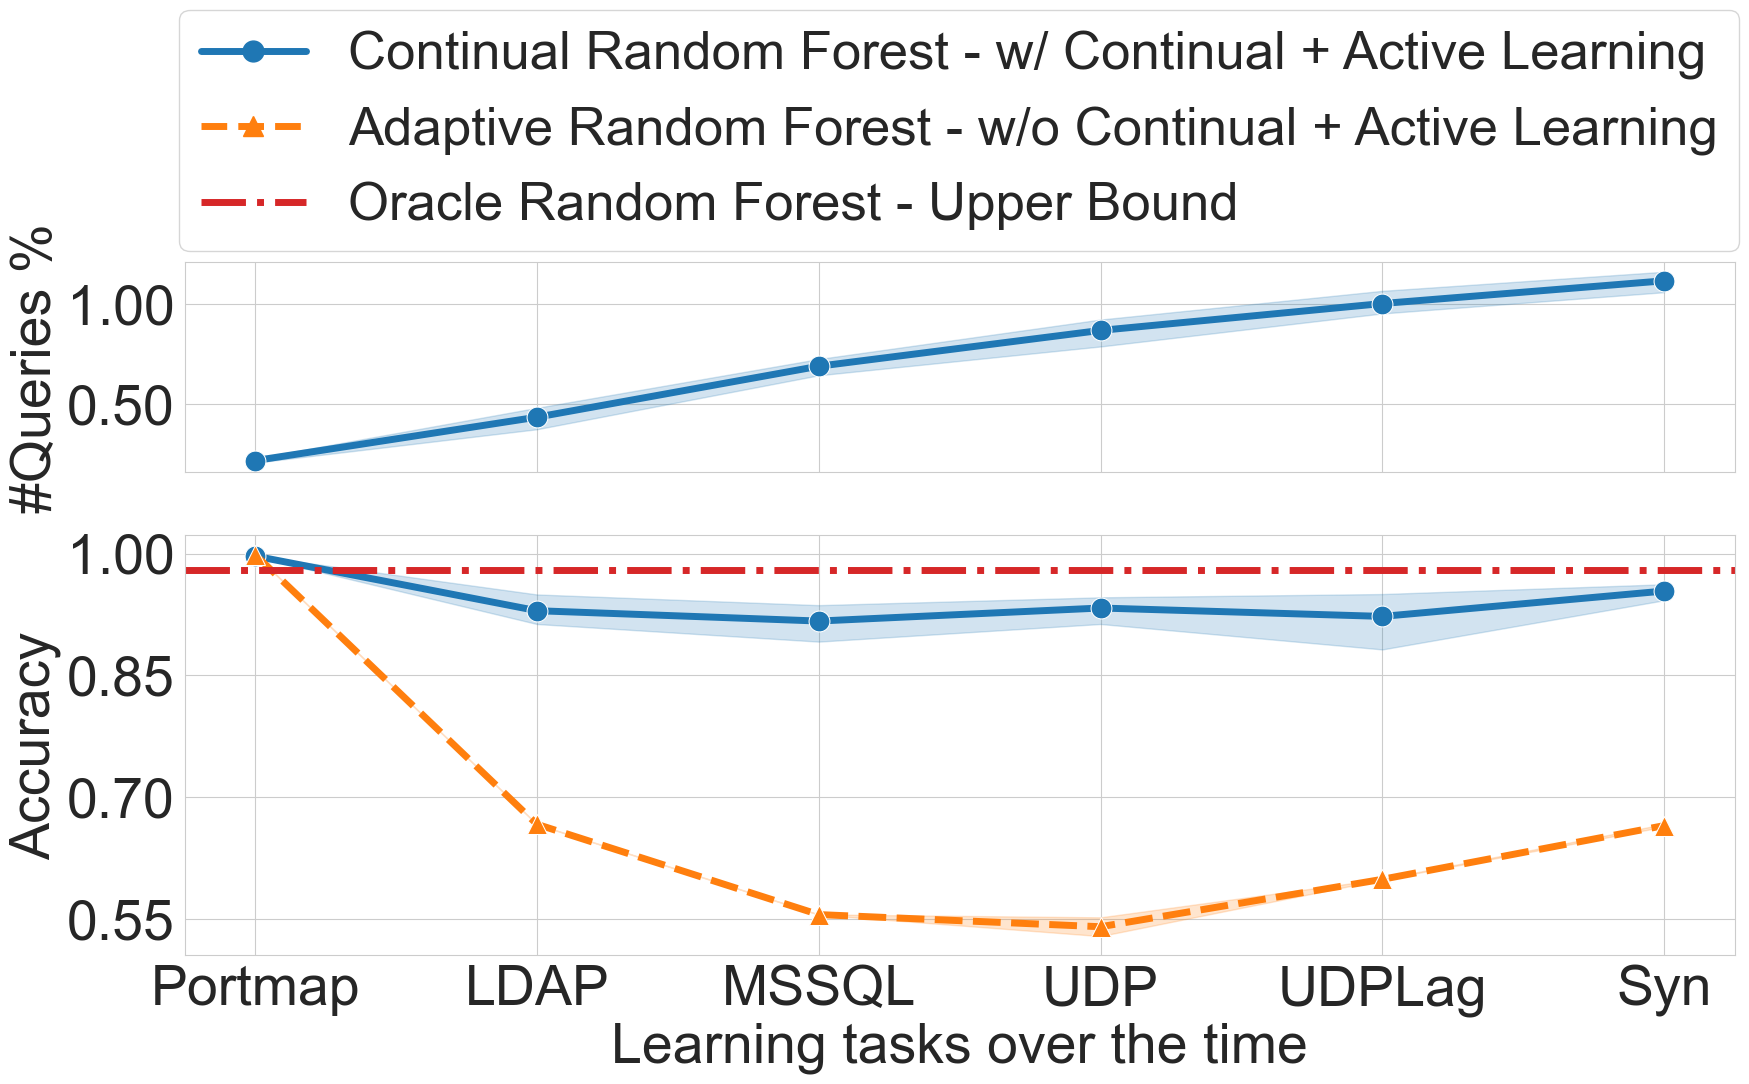

In [4]:
fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(20, 9), sharex=True, gridspec_kw={'height_ratios': [1, 2]})
sns.lineplot(x="Learning tasks over the time", y="#Queries %", style='Algorithm', data=df_size, markers='o', legend=False, ax=ax1)
sns.lineplot(x="Learning tasks over the time", y="Accuracy", hue="Algorithm", style='Algorithm', data=df, markers='o^v', legend=False, ax=ax2)
ax2.axhline(0.98, color='#d62728', linestyle='-.')
ax1.set_yticks([0.50, 1.00], ['0.50', '1.00'])
ax2.set_yticks([1.00, 0.85, 0.70, 0.55])
# make a custom legend that is the same of the second plot
from matplotlib.lines import Line2D

legend_elements = [Line2D([0], [0], color='#1f77b4', marker='o', lw=5, label='Continual Random Forest - w/ Continual + Active Learning'),
                   Line2D([0], [0], color='#ff7f0e', marker='^', lw=5, linestyle='--', label='Adaptive Random Forest - w/o Continual + Active Learning'),
                   # Line2D([0], [0], color='#2ca02c', marker='v', lw=5, linestyle=':', label='ARF - Present Tasks'),
                   Line2D([0], [0], color='#d62728', linestyle='-.', lw=5, label='Oracle Random Forest - Upper Bound')]
fig.legend(handles=legend_elements, bbox_to_anchor=(0.9155, 1.19), ncol=1, fontsize=38)
# plt.subplots_adjust(hspace=0.5)
plt.savefig("arf_crf_comparison.png", dpi=300, bbox_inches="tight")